# 🌐 Multilingual Summarization & Translation Pipeline

A production-grade NLP pipeline that:
1. **Auto-detects** the source language of any input document
2. **Summarizes** it using hierarchical chunking + mBART encoder-decoder
3. **Translates** the summary to your target language via Helsinki-NLP MarianMT
4. **Evaluates** output quality with BLEU and ROUGE-L

The custom Transformer architecture is built **from scratch** in PyTorch to demonstrate how every component works internally.

---

**Tech Stack:** PyTorch · HuggingFace Transformers · mBART · Helsinki-NLP · langdetect · NLTK

**Architecture:** Positional Encoding → Multi-Head Attention → Encoder/Decoder Stacks → Seq2Seq Output

## ⚙️ 1. Setup & Installation

In [1]:
# Install all required packages
!pip install torch transformers sentencepiece sacrebleu nltk langdetect datasets ftfy -q
print('All packages installed ✓')

All packages installed ✓


In [2]:
import sys
import ftfy
import os
import warnings
import builtins

warnings.filterwarnings('ignore')
os.environ['TRANSFORMERS_VERBOSITY'] = 'error'
os.environ['PYTHONIOENCODING'] = 'utf-8'
sys.path.insert(0, '..')  

def print(*args, **kwargs):
    fixed_args = []
    for arg in args:
        if isinstance(arg, str):
            fixed_args.append(ftfy.fix_text(arg))
        else:
            fixed_args.append(arg)
    builtins.print(*fixed_args, **kwargs)

import torch
import math


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {device}')

PyTorch version : 2.11.0+cpu
Device          : cpu


## 🧠 2. Transformer Architecture — Built From Scratch

### 2.1 Positional Encoding

Transformers have **no recurrence** — they process all tokens in parallel. Positional encoding injects order information using sine and cosine functions at different frequencies.

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

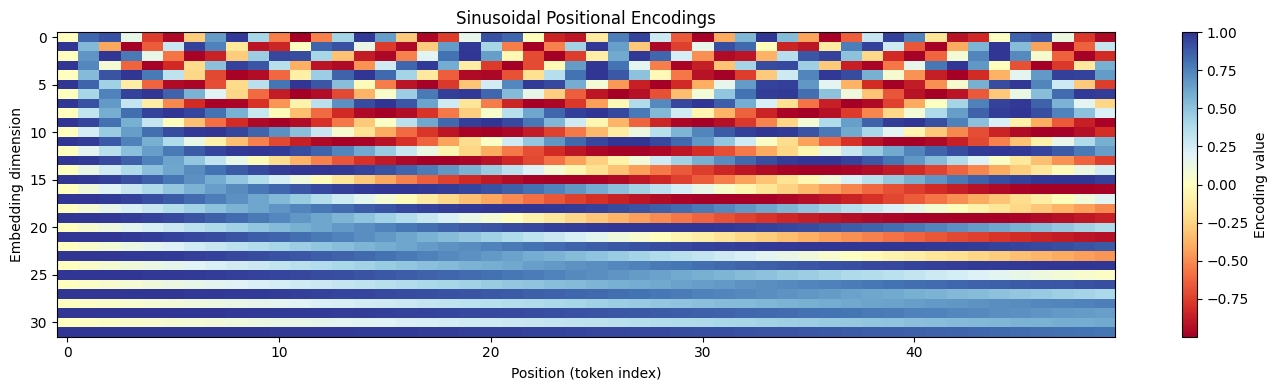

Each column = a position. Each row = a dimension. Alternating sin/cos.


In [4]:
from src.transformer import PositionalEncoding
import matplotlib.pyplot as plt
import numpy as np

# Visualize positional encodings
pe_module = PositionalEncoding(d_model=64, max_len=100)
pe_matrix = pe_module.pe.squeeze(0).numpy()   # (100, 64)

plt.figure(figsize=(14, 4))
plt.imshow(pe_matrix[:50, :32].T, aspect='auto', cmap='RdYlBu')
plt.colorbar(label='Encoding value')
plt.xlabel('Position (token index)')
plt.ylabel('Embedding dimension')
plt.title('Sinusoidal Positional Encodings')
plt.tight_layout()
plt.show()
print('Each column = a position. Each row = a dimension. Alternating sin/cos.')

### 2.2 Multi-Head Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

Multiple heads run in parallel — each learns different types of relationships (syntax, semantics, coreference, etc.).

In [5]:
from src.transformer import MultiHeadAttention

# Test multi-head attention with a dummy batch
mha = MultiHeadAttention(d_model=128, num_heads=8)

batch_size, seq_len, d_model = 2, 10, 128
query = torch.randn(batch_size, seq_len, d_model)
key   = torch.randn(batch_size, seq_len, d_model)
value = torch.randn(batch_size, seq_len, d_model)

output = mha(query, key, value)
print(f'Input shape  : {query.shape}  → (batch, seq_len, d_model)')
print(f'Output shape : {output.shape} → same as input (attention is shape-preserving)')
print(f'Attention weights shape: {mha.attn_weights.shape} → (batch, heads, seq, seq)')

Input shape  : torch.Size([2, 10, 128])  → (batch, seq_len, d_model)
Output shape : torch.Size([2, 10, 128]) → same as input (attention is shape-preserving)
Attention weights shape: torch.Size([2, 8, 10, 10]) → (batch, heads, seq, seq)


### 2.3 Full Seq2Seq Transformer

In [6]:
from src.transformer import Seq2SeqTransformer

# Build and inspect the full architecture
model = Seq2SeqTransformer(
    src_vocab_size=32000,
    tgt_vocab_size=32000,
    d_model=256,
    num_heads=8,
    num_encoder_layers=4,
    num_decoder_layers=4,
    d_ff=1024,
)
print(model)
print(f'\nTotal trainable parameters: {model.count_parameters():,}')

# Forward pass test
src = torch.randint(1, 32000, (2, 20))   # (batch=2, src_len=20)
tgt = torch.randint(1, 32000, (2, 15))   # (batch=2, tgt_len=15)
logits = model(src, tgt)
print(f'\nLogits shape: {logits.shape}  → (batch, tgt_len, vocab_size)')
print('Architecture test passed ✓')

Seq2SeqTransformer(d_model=256, params=31,971,584)

Total trainable parameters: 31,971,584

Logits shape: torch.Size([2, 15, 32000])  → (batch, tgt_len, vocab_size)
Architecture test passed ✓


## 📄 3. Hierarchical Summarization

In [7]:
from src.summarizer import MultilingualSummarizer

# This will download ~2GB mBART model on first run
summarizer = MultilingualSummarizer()

[Summarizer] Loading facebook/mbart-large-cc25 on cpu...


Loading weights:   0%|          | 0/518 [00:00<?, ?it/s]

[Summarizer] Model ready ✓


In [8]:
# Load sample English text
with open('../data/sample_texts/english_ai.txt', 'r') as f:
    english_doc = f.read()

print(f'Input: {len(english_doc.split())} words')
print('\nFirst 300 chars:')
print(english_doc[:300], '...')

Input: 331 words

First 300 chars:
Artificial intelligence is rapidly transforming industries across the globe. From healthcare
to finance, transportation to education, machine learning systems are automating complex tasks,
improving efficiency, and enabling decisions that were previously impossible at scale.

In healthcare, AI model ...


In [9]:
# Run hierarchical summarization
result = summarizer.summarize(english_doc, src_lang_code='en')

print(f"\nChunks created      : {result['num_chunks']}")
print(f"Original word count : {result['original_word_count']}")
print(f"Summary word count  : {len(result['final_summary'].split())}")
print(f"Compression ratio   : {result['compression_ratio']}")
print(f"\nFinal Summary:\n{result['final_summary']}")


[Summarizer] Input: 331 words | lang=[en]
[Summarizer] Split into 1 chunk(s)
[Summarizer] Summarizing chunk 1/1 ...
[Summarizer] Done — 36 words (compression: 0.109)

Chunks created      : 1
Original word count : 331
Summary word count  : 36
Compression ratio   : 0.109

Final Summary:
Artificial intelligence, machine learning, and machine learning systems  " are automation, and enaware, enauthorse, and intelligence systems are automating complex tasks, and automation systems are improving efficiency, and providing personalized treatment recommendations, while enalong the world—


## 🌍 4. Neural Translation

In [10]:
from src.translator import Translator

translator = Translator()

# Translate the English summary to Arabic
tr_result = translator.translate(
    text=result['final_summary'],
    src_lang='en',
    tgt_lang='ar'
)

print(f"Strategy  : {tr_result['strategy']}")
print(f"\nArabic translation:\n{tr_result['translated_text']}")

[Translator] Initialized on cpu ✓
[Translator] Loading Helsinki-NLP/opus-mt-en-ar ...


Loading weights:   0%|          | 0/258 [00:00<?, ?it/s]

[Translator] Helsinki-NLP/opus-mt-en-ar loaded ✓
Strategy  : direct

Arabic translation:
والاستخبارات الإصطناعية، والتعلم الآلي، ونظم التعلم الآلي هي نظم التشغيل الآلي، والنظم الاستخبارية والاستخبارية التي تعمل على التشغيل الآلي للمهام المعقدة، ونظم التشغيل الآلي تعمل على تحسين الكفاءة، وتقديم توصيات علاجية شخصية، في حين أنها تغطي العالم أجمع ".


In [11]:
# Try French input → English output
with open('../data/sample_texts/french_climate.txt', 'r') as f:
    french_doc = f.read()

fr_summary = summarizer.summarize(french_doc, src_lang_code='fr')
fr_to_en   = translator.translate(fr_summary['final_summary'], src_lang='fr', tgt_lang='en')

print(f"French summary  : {fr_summary['final_summary']}")
print(f"\nEnglish version : {fr_to_en['translated_text']}")


[Summarizer] Input: 272 words | lang=[fr]
[Summarizer] Split into 1 chunk(s)
[Summarizer] Summarizing chunk 1/1 ...
[Summarizer] Done — 63 words (compression: 0.232)
[Translator] Loading Helsinki-NLP/opus-mt-fr-en ...


Loading weights:   0%|          | 0/256 [00:00<?, ?it/s]

[Translator] Helsinki-NLP/opus-mt-fr-en loaded ✓
French summary  : Le changement de l'écécleclecleévals du changement de la crise du changement climatique, l'est-la guerre du changement dégécoupévolutions de notre épopoule mondiale. Pour faire face à la crise, une crise, à l'emécrimémenées par les activitéveloppement des ìnélioration de lénements et les transports, la réduction de la biodiversiténergies renouvelables comme l'extinction. Les à des vagues de chaleur qui poussent de nombreuses espà ̈ces vers l'

English version : The change of the key to changing the climate change crisis, the war of change cut across the evolutions of our global populace. To deal with the crisis, a crisis, to be addressed by the activities of improving events and transportation, the reduction of renewable energy biodiversity such as extinction. The heat waves that push many species towards extinction.


## 🔁 5. Full Pipeline (One Call)

In [12]:
from src.pipeline import MultilingualPipeline

pipeline = MultilingualPipeline(lazy_load=True)  # reuses already-loaded models
pipeline._summarizer = summarizer
pipeline._translator = translator

full_result = pipeline.run(
    text=english_doc,
    target_language='arabic',
    verbose=True
)

[Pipeline] Running on: cpu

[Pipeline] Step 1/3 — Detecting source language...
[Pipeline] Detected: English (100.0% confidence)

[Pipeline] Step 2/3 — Summarizing...

[Summarizer] Input: 331 words | lang=[en]
[Summarizer] Split into 1 chunk(s)
[Summarizer] Summarizing chunk 1/1 ...
[Summarizer] Done — 36 words (compression: 0.109)

[Pipeline] Step 3/3 — Translating to [arabic]...

  MULTILINGUAL SUMMARIZATION & TRANSLATION — RESULTS

  Source language    : English [en]  (confidence: 100.0%)
  Target language    : arabic
  Original length    : 331 words
  Summary length     : 36 words
  Compression ratio  : 0.109
  Translation strat. : direct

─────────────────────────────────────────────────────────────────
  SUMMARY (source language)
─────────────────────────────────────────────────────────────────

  Artificial intelligence, machine learning, and machine learning systems â€€” are automation, and enaware, enauthorse, and intelligence systems are automating complex tasks, and automatio

## 📊 6. Evaluation — BLEU & ROUGE-L

In [13]:
from src.utils import bleu_score, rouge_l

# Compare our summary translation against a reference (human translation)
hypothesis = full_result['translation']['translated_text']

# Example reference (replace with real human translation for fair evaluation)
reference = (
    "يحول الذكاء الاصطناعي الصناعات في جميع أنحاء العالم، "
    "من الرعاية الصحية إلى المالية والتعليم والمناخ."
)

bleu   = bleu_score(hypothesis, reference)
rouge  = rouge_l(hypothesis, reference)

print(f"BLEU Score     : {bleu['bleu']}")
print(f"N-gram prec.   : {bleu['precisions']}  (1-gram to 4-gram)")
print(f"Brevity penalty: {bleu['brevity_penalty']}")
print(f"\nROUGE-L F1     : {rouge['rouge_l_f1']}")
print(f"ROUGE Precision: {rouge['rouge_l_precision']}")
print(f"ROUGE Recall   : {rouge['rouge_l_recall']}")

BLEU Score     : 0.0
N-gram prec.   : [2.56, 0.0, 0.0, 0.0]  (1-gram to 4-gram)
Brevity penalty: 1.0

ROUGE-L F1     : 0.037
ROUGE Precision: 0.0256
ROUGE Recall   : 0.0667


## 📐 7. Architecture Deep-Dive: Attention Visualization

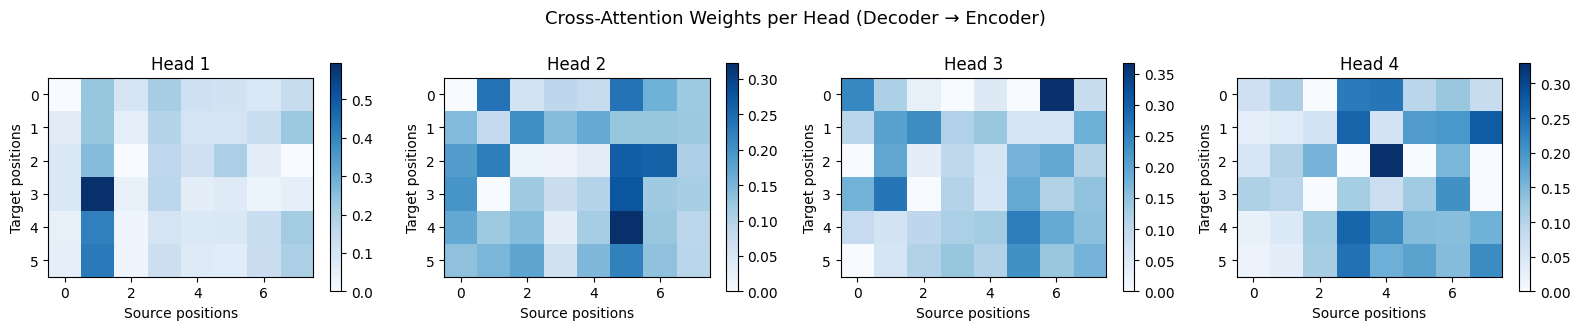

Each head attends to different source positions — specialization emerges through training.


In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Show attention weight matrix for a small custom transformer
tiny_model = Seq2SeqTransformer(
    src_vocab_size=100, tgt_vocab_size=100,
    d_model=32, num_heads=4,
    num_encoder_layers=1, num_decoder_layers=1, d_ff=64
)

src = torch.randint(1, 100, (1, 8))   # batch=1, seq=8
tgt = torch.randint(1, 100, (1, 6))
_ = tiny_model(src, tgt)

# Get attention weights from the first decoder cross-attention layer
attn_weights = tiny_model.decoder_layers[0].cross_attn.attn_weights  # (1, heads, tgt_len, src_len)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for head_idx in range(4):
    ax = axes[head_idx]
    weights = attn_weights[0, head_idx].detach().numpy()
    im = ax.imshow(weights, cmap='Blues', vmin=0, vmax=weights.max())
    ax.set_title(f'Head {head_idx + 1}')
    ax.set_xlabel('Source positions')
    ax.set_ylabel('Target positions')
    plt.colorbar(im, ax=ax)

plt.suptitle('Cross-Attention Weights per Head (Decoder → Encoder)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print('Each head attends to different source positions — specialization emerges through training.')

## 📋 8. Summary of Supported Language Pairs

In [15]:
import pandas as pd
from src.translator import LANGUAGE_NAME_TO_CODE

data = [
    ('English', 'en',  'Arabic, French, Spanish, German, Chinese, Japanese, Russian, Portuguese, Italian'),
    ('Arabic',  'ar',  'English, French'),
    ('French',  'fr',  'English, Spanish, German, Arabic, Italian'),
    ('Spanish', 'es',  'English, French, Portuguese, Italian'),
    ('German',  'de',  'English, French, Russian'),
    ('Chinese', 'zh',  'English (pivot for others)'),
    ('Russian', 'ru',  'English, German'),
    ('Japanese','ja',  'English (pivot for others)'),
]

df = pd.DataFrame(data, columns=['Language', 'ISO Code', 'Direct Translation Targets'])
display(df)
print('\nAll other pairs are handled via English pivot translation.')

,Language,ISO Code,Direct Translation Targets
0,English,en,"Arabic, French, Spanish, German, Chinese, Japa..."
1,Arabic,ar,"English, French"
2,French,fr,"English, Spanish, German, Arabic, Italian"
3,Spanish,es,"English, French, Portuguese, Italian"
4,German,de,"English, French, Russian"
5,Chinese,zh,English (pivot for others)
6,Russian,ru,"English, German"
7,Japanese,ja,English (pivot for others)



All other pairs are handled via English pivot translation.
